# Sprint 2a — Carimbamento dos Dados com Preditor de Dureza SAG

**Objetivo:** Aplicar o sistema de classificação de dureza por energia específica (C1-C6)
sobre os dados limpos do moinho de bolas, gerando labels supervisionados para a etapa
de modelagem.

**Entradas:**
- `dados_limpos` via PostgreSQL (saída do S1a — 632.985 registros, 27 variáveis)
- `s1c_v2_dados_com_clusters` — regimes do clustering V2

**Saídas:**
- Dataset rotulado com classes C1-C6 + metadados do preditor
- Comparação quantitativa entre regimes (clustering) e classes SAG

**Métricas de concordância:**
- **ARI (Adjusted Rand Index):** concordância ajustada por chance (-1 a 1)
- **NMI (Normalized Mutual Information):** informação mútua normalizada (0 a 1)
- **V de Cramér:** associação entre variáveis categóricas baseada no qui-quadrado (0 a 1)

**Visualizações:**
- Heatmap da contingência normalizada por linha (distribuição de classes SAG dentro de cada regime)
- Heatmap da contingência normalizada por coluna (distribuição de regimes dentro de cada classe SAG)
- Boxplot de energia específica por regime
- Barras empilhadas: composição de classes SAG por regime

**Pipeline:**
1. Configurar preditor de dureza (faixas C1-C6, limites operacionais)
2. Executar preditor de dureza em modo backtesting (adaptado para 1 min)
3. Analisar distribuição de classes e estabilidade
4. Comparar com regimes do clustering V2 (ARI, NMI, V de Cramér)
5. Definir target para classificação supervisionada
6. Salvar dataset rotulado

## 1. Setup

**Objetivo:** Configurar o ambiente de execução, importando as bibliotecas necessárias para
a análise de concordância — NumPy, Pandas, Matplotlib, Seaborn, métricas do scikit-learn
(ARI, NMI) e SciPy (qui-quadrado para V de Cramér). Conecto ao PostgreSQL via db_utils
para carregar os dados de clustering V2 e o dataset com as classes SAG.

In [14]:
# ==============================================================================
# Setup: caminhos e imports
# ==============================================================================
import sys, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")
DATA_RAW    = PROJECT_ROOT / "data" / "raw"
DATA_PROC   = PROJECT_ROOT / "data" / "processed"
DATA_LABEL  = PROJECT_ROOT / "data" / "labeled"
FIGURES_DIR = PROJECT_ROOT / "figures" / "02_sprint2"
MODELS_DIR  = PROJECT_ROOT / "models"

for d in [DATA_LABEL, FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import chi2_contingency

# Acesso ao banco de dados
SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))
from db_utils import carregar_dados, salvar_dataframe, salvar_imagem, criar_tabelas

criar_tabelas()

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 19,
    "figure.titlesize": 21,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
STAGE = "s2a"
t0 = time.time()
print("=" * 60)
print("  S2a — CARIMBAMENTO COM PREDITOR DE DUREZA SAG")
print("=" * 60)

[db_utils] Schema 'otimizar_moagem_aura' e tabelas criados/verificados com sucesso
  S2a — CARIMBAMENTO COM PREDITOR DE DUREZA SAG


## 2. Configuração do Preditor de Dureza

**Origem:** Sistema de classificação em operação na planta, baseado em energia específica.

**Lógica do preditor (adaptada para dados de 1 minuto):**
1. Janela deslizante de 5 minutos
2. Verificação de estabilidade: CV(alimentação) < 5%, alimentação > 200 t/h, potência > 2.000 kW
3. Cálculo de energia específica: potência / alimentação (kWh/t)
4. Suavização EMA (α = 0.1)
5. Classificação em 6 classes (C1-C6) por faixas de energia

| Classe | Nome | Energia (kWh/t) | Capacidade máx. (t/h) |
|--------|------|-----------------|----------------------|
| C1 | Muito Macio | < 8.31 | 417 |
| C2 | Macio | 8.31 – 8.84 | 371 |
| C3 | Médio | 8.84 – 9.27 | 353 |
| C4 | Duro | 9.27 – 9.67 | 338 |
| C5 | Muito Duro | 9.67 – 10.18 | 323 |
| C6 | Extremamente Duro | > 10.18 | 296 |

In [15]:
# ==============================================================================
# Parâmetros do preditor (replicados do sistema em produção)
# ==============================================================================

# Faixas de energia específica para classificação (kWh/t)
ENERGY_THRESHOLDS = [0, 8.31, 8.84, 9.27, 9.67, 10.18, float("inf")]

# Tabela de classes
CLASSES_SAG = {
    1: {"nome": "Muito Macio",       "energia_media": 7.67, "capacidade": 417, "cor": "#22c55e"},
    2: {"nome": "Macio",             "energia_media": 8.63, "capacidade": 371, "cor": "#84cc16"},
    3: {"nome": "Médio",             "energia_media": 9.08, "capacidade": 353, "cor": "#eab308"},
    4: {"nome": "Duro",              "energia_media": 9.48, "capacidade": 338, "cor": "#f97316"},
    5: {"nome": "Muito Duro",        "energia_media": 9.92, "capacidade": 323, "cor": "#ef4444"},
    6: {"nome": "Extremamente Duro", "energia_media": 10.82, "capacidade": 296, "cor": "#991b1b"},
}
CORES_CLASSE = [CLASSES_SAG[i]["cor"] for i in range(1, 7)]

# Limites operacionais
LIMITES = {
    "potencia_max": 3200,
    "potencia_min": 2000,
    "alimentacao_min": 200,
    "mancal_partida": 55,
    "cv_max": 0.05,
}

# Parâmetros do preditor
JANELA_MIN = 5
EMA_ALPHA = 0.1

# Mapeamento de colunas do dataset
COL_MAP = {
    "alimentacao": "1025_RETOMADA _ TR02 _ BALANÇA_pipoint",
    "potencia":    "1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint",
    "mancal":      "1030_MOAGEM _ MO01MANCALSAÍDA _ PRESSÃO_pipoint",
}

# Regimes do clustering V2
REGIME_NAMES = {0: "Carga Reduzida", 1: "Moderado", 2: "Alta Carga"}
REGIME_COLORS = ["#66c2a5", "#fc8d62", "#8da0cb"]
N_REGIMES = 3

print("Configuração do preditor:")
print(f"  Classes SAG: C1-C6 (6 faixas de energia específica)")
print(f"  Janela de estabilidade: {JANELA_MIN} min")
print(f"  EMA alpha: {EMA_ALPHA}")
print(f"  CV máximo: {LIMITES['cv_max']*100:.0f}%")
print(f"\nClustering V2: {N_REGIMES} regimes")
for r, nome in REGIME_NAMES.items():
    print(f"  R{r}: {nome}")

Configuração do preditor:
  Classes SAG: C1-C6 (6 faixas de energia específica)
  Janela de estabilidade: 5 min
  EMA alpha: 0.1
  CV máximo: 5%

Clustering V2: 3 regimes
  R0: Carga Reduzida
  R1: Moderado
  R2: Alta Carga


## 3. Carga dos Dados

**Objetivo:** Carregar dois datasets do PostgreSQL:
1. `dados_limpos` — 632.985 registros com as 27 variáveis de processo (saída do S1a)
2. `s1c_v2_dados_com_clusters` — dataset com os regimes atribuídos pelo clustering V2

O preditor de dureza será executado sobre os dados limpos, e os regimes do clustering V2
serão utilizados para a comparação.

In [16]:
# Carregar dataset limpo do PostgreSQL (saída do S1a)
df = carregar_dados("dados_limpos")
df = df.drop(columns=["id"], errors="ignore")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()

# Verificar colunas necessárias
for var, col in COL_MAP.items():
    assert col in df.columns, f"Coluna '{col}' não encontrada para variável '{var}'"

print(f"Dataset limpo: {df.shape[0]:,} registros x {df.shape[1]} colunas")
print(f"Período: {df.index.min()} a {df.index.max()}")

# Carregar clusters V2
df_clusters = carregar_dados("s1c_v2_dados_com_clusters")
df_clusters = df_clusters.drop(columns=["id"], errors="ignore")
df_clusters["Timestamp"] = pd.to_datetime(df_clusters["Timestamp"])
df_clusters = df_clusters.set_index("Timestamp")[["regime"]]
df_clusters = df_clusters[df_clusters["regime"].notna()]
df_clusters["regime"] = df_clusters["regime"].astype(int)

# Juntar regimes ao dataset principal
df["regime"] = df_clusters["regime"]

print(f"\nClustering V2: {df_clusters.shape[0]:,} registros com regime atribuído")
for r in sorted(df_clusters["regime"].unique()):
    n = (df_clusters["regime"] == r).sum()
    print(f"  R{r} ({REGIME_NAMES[r]:15s}): {n:>8,} ({100*n/len(df_clusters):.1f}%)")

[db_utils] 632985 linhas carregadas de otimizar_moagem_aura.dados_limpos
Dataset limpo: 632,985 registros x 27 colunas
Período: 2024-08-01 00:00:00 a 2026-03-01 00:00:00
[db_utils] 632985 linhas carregadas de otimizar_moagem_aura.s1c_v2_dados_com_clusters

Clustering V2: 632,985 registros com regime atribuído
  R0 (Carga Reduzida ):   90,119 (14.2%)
  R1 (Moderado       ):  288,740 (45.6%)
  R2 (Alta Carga     ):  254,126 (40.1%)


## 4. Backtesting do Preditor de Dureza

**Objetivo:** Executar o preditor de dureza sobre todo o histórico de dados limpos,
classificando cada minuto em uma das 6 classes de dureza (C1-C6).

**Adaptação para dados de 1 minuto:**
O preditor em produção opera com dados a cada 10 segundos (6 pts/min).
Para o backtesting com dados de 1 minuto, a janela de 5 minutos usa 5 pontos
em vez de 30, e o EMA é aplicado com o mesmo α = 0.1.

**Critérios de estabilidade (mesmo da produção):**
- CV(alimentação) < 5% na janela de 5 min
- Alimentação média > 200 t/h
- Potência média > 2.000 kW
- Mancal ≤ 55 bar (acima = partida do moinho)

In [17]:
def classificar_energia(energia):
    """Classifica energia específica em classe C1-C6."""
    for i in range(1, 7):
        if energia < ENERGY_THRESHOLDS[i]:
            return i
    return 6


def backtesting_preditor(df, janela=JANELA_MIN, alpha=EMA_ALPHA):
    """
    Executa o preditor de dureza em modo backtesting sobre dados de 1 minuto.
    Retorna colunas: energia_raw, energia_ema, cv_alimentacao, is_stable, classe_sag, capacidade_max
    """
    col_alim = COL_MAP["alimentacao"]
    col_pot  = COL_MAP["potencia"]
    col_mancal = COL_MAP["mancal"]

    n = len(df)
    alim = df[col_alim].values
    pot  = df[col_pot].values
    mancal = df[col_mancal].values

    energia_raw = np.full(n, np.nan)
    energia_ema = np.full(n, np.nan)
    cv_alim = np.full(n, np.nan)
    is_stable = np.zeros(n, dtype=bool)
    classe_sag = np.full(n, np.nan)
    capacidade_max = np.full(n, np.nan)

    ema_atual = None

    for i in range(n):
        # Período de partida — não classificar
        if mancal[i] > LIMITES["mancal_partida"]:
            if ema_atual is not None:
                energia_ema[i] = ema_atual
                capacidade_max[i] = LIMITES["potencia_max"] / ema_atual
            continue

        # Precisa de janela completa
        if i < janela:
            continue

        # Janela de 5 minutos
        win_alim = alim[i - janela + 1 : i + 1]
        win_pot = pot[i - janela + 1 : i + 1]

        alim_mean = np.nanmean(win_alim)
        alim_std = np.nanstd(win_alim)
        pot_mean = np.nanmean(win_pot)

        cv = alim_std / alim_mean if alim_mean > 0 else 1.0
        cv_alim[i] = cv

        # Verificar estabilidade
        stable = (
            cv < LIMITES["cv_max"]
            and alim_mean > LIMITES["alimentacao_min"]
            and pot_mean > LIMITES["potencia_min"]
        )
        is_stable[i] = stable

        # Energia específica
        e_raw = pot_mean / alim_mean if alim_mean > 0 else np.nan
        energia_raw[i] = e_raw

        if stable and not np.isnan(e_raw):
            # EMA
            if ema_atual is None:
                ema_atual = e_raw
            else:
                ema_atual = alpha * e_raw + (1 - alpha) * ema_atual

            energia_ema[i] = ema_atual
            classe_sag[i] = classificar_energia(ema_atual)
            capacidade_max[i] = LIMITES["potencia_max"] / ema_atual
        else:
            # Instável — manter último EMA mas não classificar
            if ema_atual is not None:
                energia_ema[i] = ema_atual
                capacidade_max[i] = LIMITES["potencia_max"] / ema_atual

    return {
        "energia_raw": energia_raw,
        "energia_ema": energia_ema,
        "cv_alimentacao": cv_alim,
        "is_stable": is_stable,
        "classe_sag": classe_sag,
        "capacidade_max": capacidade_max,
    }


print("Executando backtesting do preditor de dureza...")
t_bt = time.time()
result = backtesting_preditor(df)

# Adicionar colunas ao DataFrame
for col, values in result.items():
    df[col] = values

elapsed_bt = time.time() - t_bt
print(f"  Tempo: {elapsed_bt:.1f}s")
print(f"  Registros classificados: {df['classe_sag'].notna().sum():,} ({100*df['classe_sag'].notna().sum()/len(df):.1f}%)")
print(f"  Estáveis: {df['is_stable'].sum():,} ({100*df['is_stable'].sum()/len(df):.1f}%)")

Executando backtesting do preditor de dureza...
  Tempo: 24.7s
  Registros classificados: 359,360 (56.8%)
  Estáveis: 359,360 (56.8%)


## 5. Análise da Distribuição de Classes SAG

**Objetivo:** Analisar como as 6 classes de dureza SAG (C1 — Muito Macio a C6 — Extremamente Duro) se distribuem no dataset após o backtesting. Avalio o balanceamento entre classes e o percentual de períodos estáveis vs. instáveis, verificando se a distribuição resultante é viável como variável-alvo para modelagem supervisionada.

**Justificativa:** Compreender a distribuição de classes é essencial antes de qualquer decisão sobre o target de classificação. Classes fortemente desbalanceadas ou com baixa estabilidade operacional poderiam comprometer o treinamento de modelos supervisionados. A análise inclui: (a) contagem e proporção de cada classe, (b) histograma de energia específica com as faixas de corte, e (c) proporção de registros estáveis — critério que indica a confiabilidade da classificação atribuída pelo preditor.

Distribuição das classes de dureza SAG:
  C1 (Muito Macio         ):   74,750 ( 20.8%)
  C2 (Macio               ):   51,009 ( 14.2%)
  C3 (Médio               ):   47,205 ( 13.1%)
  C4 (Duro                ):   42,401 ( 11.8%)
  C5 (Muito Duro          ):   47,162 ( 13.1%)
  C6 (Extremamente Duro   ):   96,833 ( 26.9%)

Estabilidade:
  Estável:    359,360 (56.8%)
  Instável:   273,625 (43.2%)
[db_utils] Imagem 'distribuicao_classes_sag' salva para etapa s2a


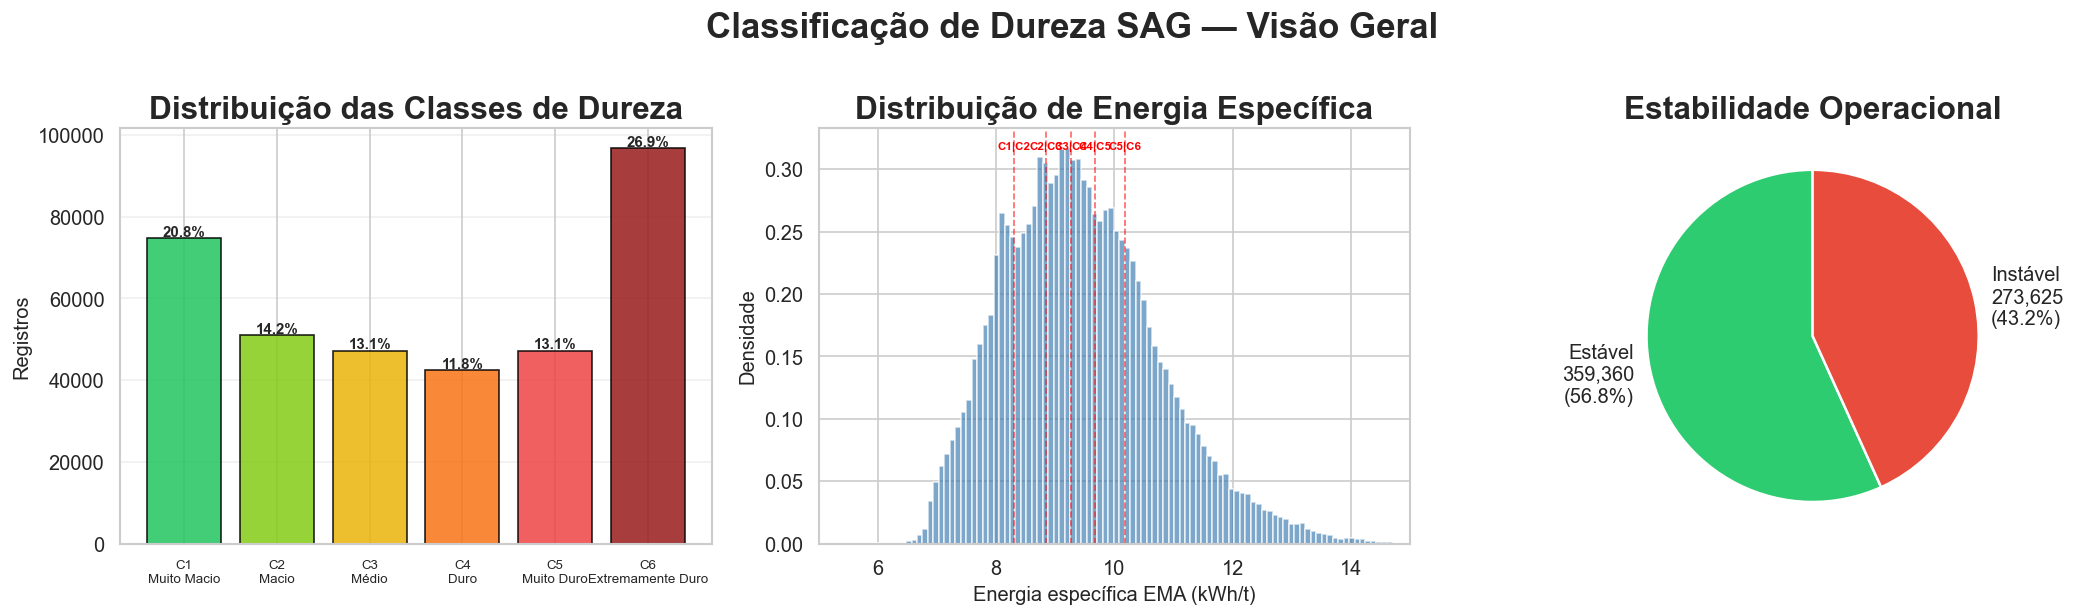

In [18]:
# Distribuição de classes (apenas registros com classe atribuída)
df_class = df[df["classe_sag"].notna()].copy()
df_class["classe_sag"] = df_class["classe_sag"].astype(int)

dist_classes = df_class["classe_sag"].value_counts().sort_index()
dist_pct = 100 * dist_classes / len(df_class)

print("Distribuição das classes de dureza SAG:")
print("=" * 60)
for c in range(1, 7):
    n = dist_classes.get(c, 0)
    pct = dist_pct.get(c, 0)
    print(f"  C{c} ({CLASSES_SAG[c]['nome']:20s}): {n:>8,} ({pct:5.1f}%)")

# Distribuição de estabilidade
n_stable = df["is_stable"].sum()
n_unstable = (~df["is_stable"]).sum()
print(f"\nEstabilidade:")
print(f"  Estável:   {n_stable:>8,} ({100*n_stable/len(df):.1f}%)")
print(f"  Instável:  {n_unstable:>8,} ({100*n_unstable/len(df):.1f}%)")

# --- Visualização ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 5a. Barras: distribuição de classes
ax = axes[0]
bars = ax.bar(range(1, 7), [dist_classes.get(i, 0) for i in range(1, 7)],
              color=CORES_CLASSE, edgecolor="black", alpha=0.85)
for bar, c in zip(bars, range(1, 7)):
    pct = dist_pct.get(c, 0)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{pct:.1f}%", ha="center", fontweight="bold", fontsize=9)
ax.set_xticks(range(1, 7))
ax.set_xticklabels([f"C{i}\n{CLASSES_SAG[i]['nome']}" for i in range(1, 7)], fontsize=8)
ax.set_ylabel("Registros")
ax.set_title("Distribuição das Classes de Dureza", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

# 5b. Histograma de energia específica com faixas
ax = axes[1]
energia_valid = df_class["energia_ema"].dropna()
ax.hist(energia_valid, bins=100, color="steelblue", alpha=0.7, density=True, edgecolor="white")
for i in range(1, 6):
    ax.axvline(ENERGY_THRESHOLDS[i], color="red", linestyle="--", alpha=0.6, linewidth=1)
    ax.text(ENERGY_THRESHOLDS[i], ax.get_ylim()[1]*0.95, f"C{i}|C{i+1}",
            ha="center", fontsize=7, color="red", fontweight="bold")
ax.set_xlabel("Energia específica EMA (kWh/t)")
ax.set_ylabel("Densidade")
ax.set_title("Distribuição de Energia Específica", fontweight="bold")
ax.set_xlim(5, 15)

# 5c. Pie: estável vs instável
ax = axes[2]
sizes = [n_stable, n_unstable]
labels_pie = [f"Estável\n{n_stable:,}\n({100*n_stable/len(df):.1f}%)",
              f"Instável\n{n_unstable:,}\n({100*n_unstable/len(df):.1f}%)"]
ax.pie(sizes, labels=labels_pie, colors=["#2ecc71", "#e74c3c"], autopct="",
       startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Estabilidade Operacional", fontweight="bold")

fig.suptitle("Classificação de Dureza SAG — Visão Geral", fontsize=21, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S2a_01_distribuicao_classes_sag.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "distribuicao_classes_sag", fig, "S2a_01_distribuicao_classes_sag.png")
plt.show()

## 6. Evolução Temporal das Classes SAG

**Objetivo:** Visualizar a evolução das classes de dureza ao longo do tempo por meio de três subplots complementares: (1) série temporal da energia específica EMA com as faixas de corte C1-C6, (2) scatter plot da classe atribuída a cada hora, e (3) proporção mensal empilhada das classes.

**Justificativa:** A análise temporal revela se as classes SAG apresentam padrões sazonais, tendências de longo prazo ou comportamento altamente oscilatório. Classes que alternam rapidamente entre extremos indicam que o preditor é sensível a flutuações de curto prazo, o que pode limitar sua utilidade como target estável para classificação supervisionada. A visão mensal permite identificar se a composição de dureza varia ao longo dos meses — reflexo de mudanças na frente de lavra ou na blendagem do ROM.

[db_utils] Imagem 'evolucao_temporal_sag' salva para etapa s2a


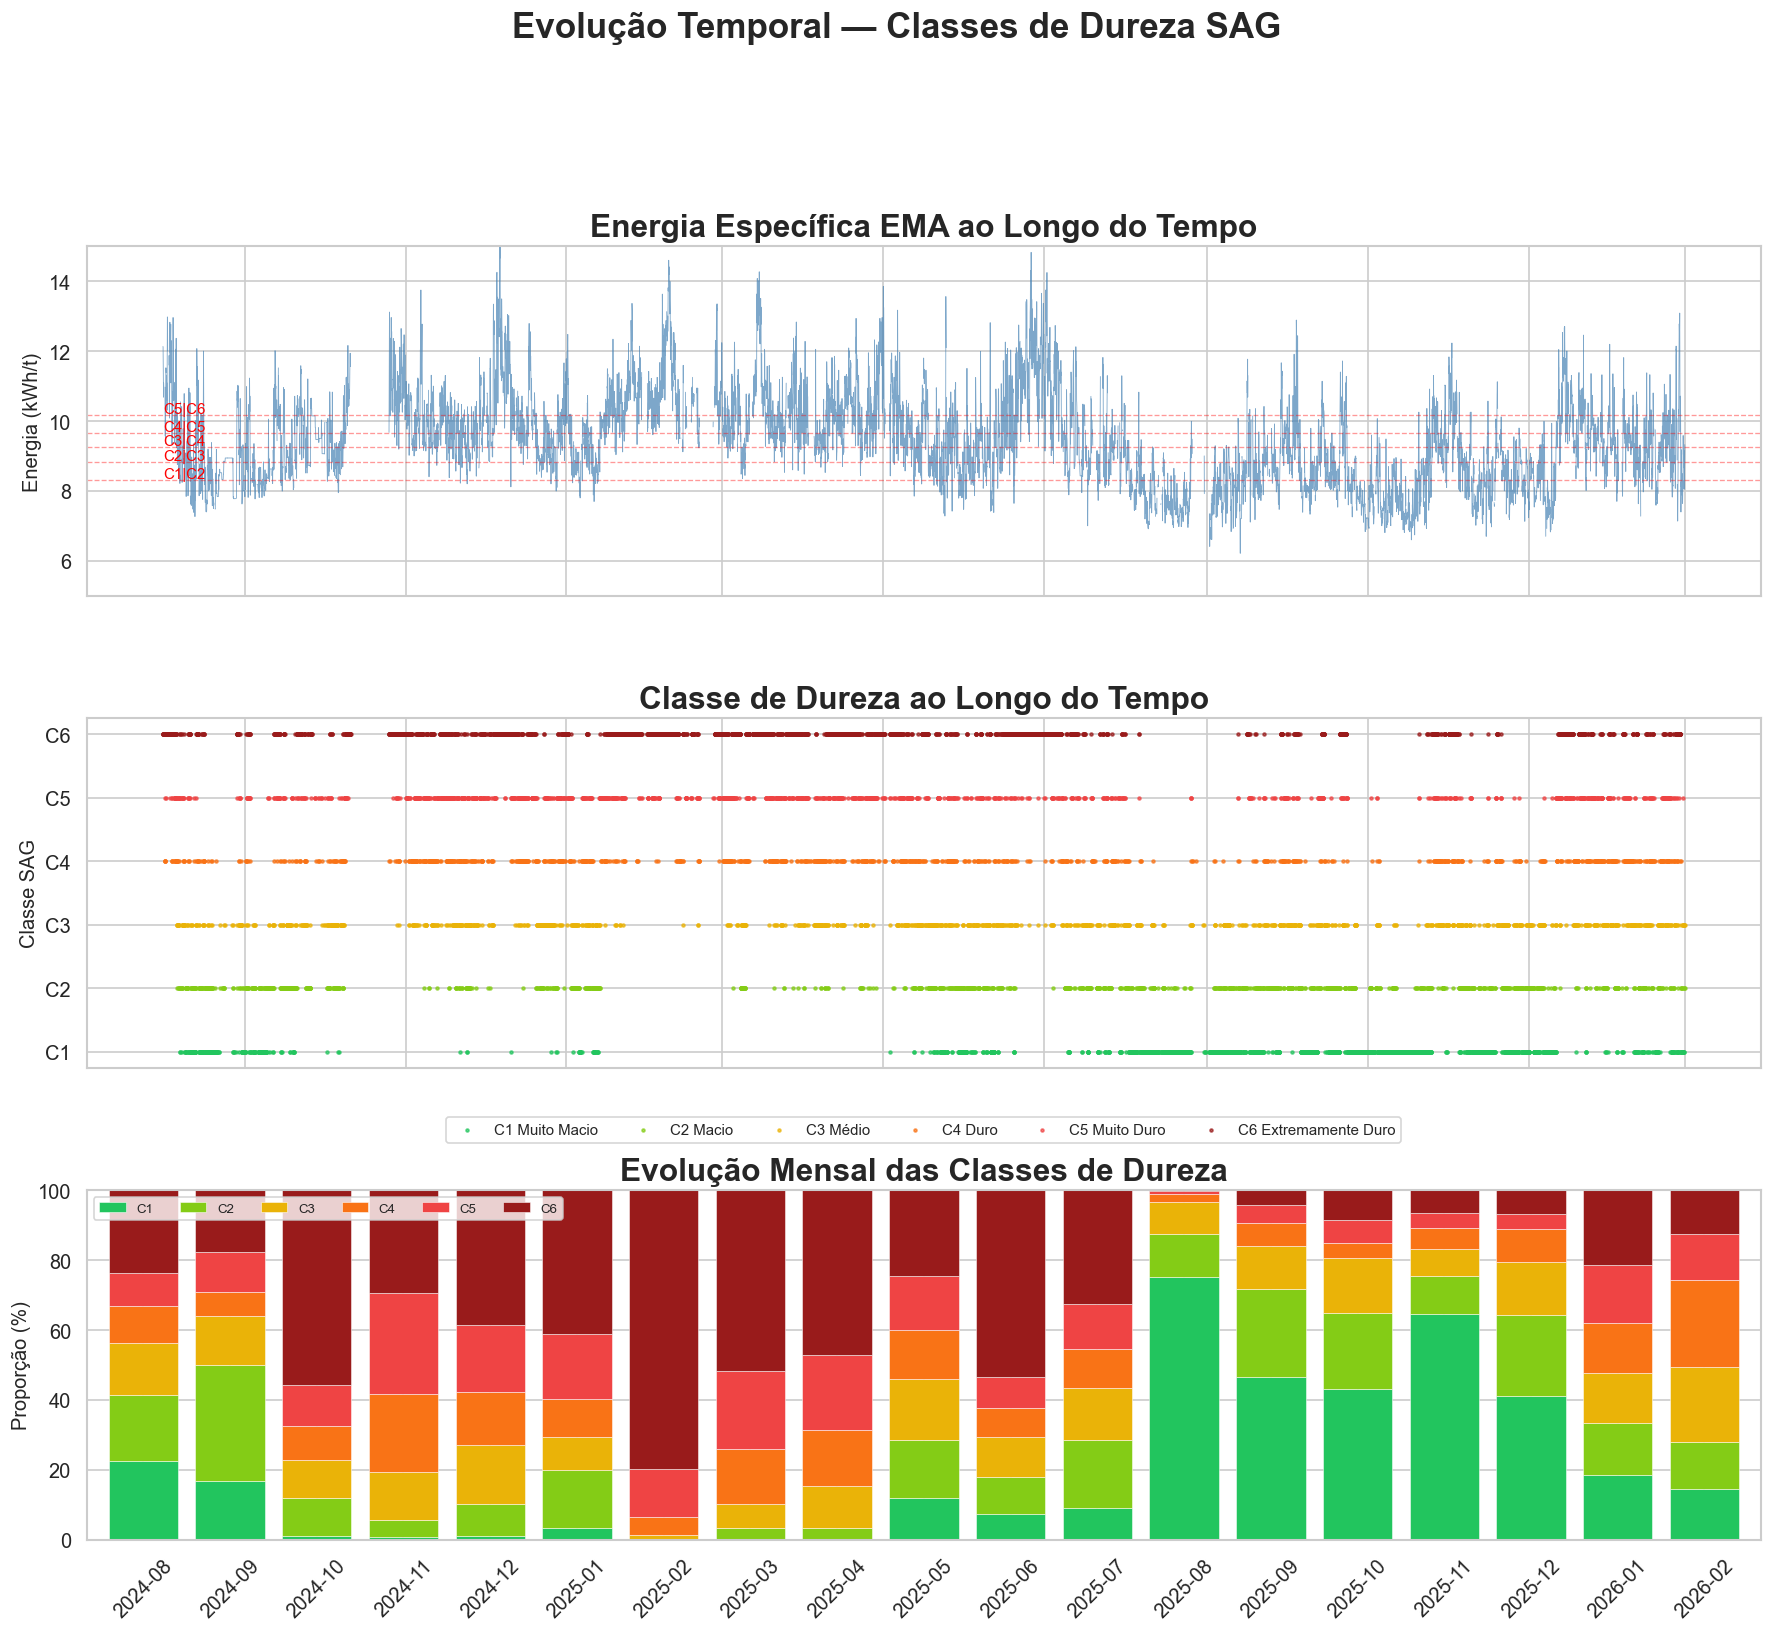

In [19]:
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1], hspace=0.35)

# 6a. Energia específica EMA ao longo do tempo
ax = fig.add_subplot(gs[0])
energia_h = df["energia_ema"].resample("1h").mean()
ax.plot(energia_h.index, energia_h.values, color="steelblue", linewidth=0.5, alpha=0.7)
for i in range(1, 6):
    ax.axhline(ENERGY_THRESHOLDS[i], color="red", linestyle="--", alpha=0.4, linewidth=0.8)
    ax.text(energia_h.index[0], ENERGY_THRESHOLDS[i] + 0.05, f"C{i}|C{i+1}",
            fontsize=9, color="red")
ax.set_ylabel("Energia (kWh/t)")
ax.set_title("Energia Específica EMA ao Longo do Tempo", fontweight="bold")
ax.set_ylim(5, 15)
ax.tick_params(axis="x", rotation=20)

# 6b. Classe SAG ao longo do tempo (scatter)
ax = fig.add_subplot(gs[1], sharex=fig.axes[0])
def safe_mode(x):
    vals = x.dropna()
    if len(vals) == 0:
        return np.nan
    m = vals.mode()
    return m.iloc[0] if len(m) > 0 else np.nan

classe_h = df["classe_sag"].resample("1h").apply(safe_mode)
for c in range(1, 7):
    mask = classe_h == c
    ax.scatter(classe_h.index[mask], classe_h.values[mask], c=CLASSES_SAG[c]["cor"],
              s=3, alpha=0.7, label=f"C{c} {CLASSES_SAG[c]['nome']}")
ax.set_yticks(range(1, 7))
ax.set_yticklabels([f"C{i}" for i in range(1, 7)])
ax.set_ylabel("Classe SAG")
ax.set_title("Classe de Dureza ao Longo do Tempo", fontweight="bold")
ax.legend(fontsize=9, ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.12))

# 6c. Proporção mensal (eixo independente — categórico)
ax = fig.add_subplot(gs[2])
df_with_class = df[df["classe_sag"].notna()].copy()
df_with_class["classe_sag_int"] = df_with_class["classe_sag"].astype(int)
df_with_class["mes_str"] = df_with_class.index.to_period("M").astype(str)
mensal = df_with_class.groupby(["mes_str", "classe_sag_int"]).size().unstack(fill_value=0)
mensal_pct = mensal.div(mensal.sum(axis=1), axis=0) * 100
mensal_pct.plot(kind="bar", stacked=True, color=CORES_CLASSE, ax=ax, width=0.8,
                edgecolor="white", linewidth=0.3)
ax.set_ylabel("Proporção (%)")
ax.set_xlabel("")
ax.set_title("Evolução Mensal das Classes de Dureza", fontweight="bold")
ax.legend([f"C{i}" for i in range(1, 7)], fontsize=8, ncol=6)
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=45)

fig.suptitle("Evolução Temporal — Classes de Dureza SAG", fontsize=21, fontweight="bold", y=1.02)
fig.savefig(FIGURES_DIR / "S2a_02_evolucao_temporal_sag.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "evolucao_temporal_sag", fig, "S2a_02_evolucao_temporal_sag.png")
plt.show()

## 7. Métricas de Concordância: Clustering V2 vs Classes SAG

**Objetivo:** Quantificar o grau de associação entre os regimes do clustering V2
e as classes de dureza SAG (C1-C6) por meio de três métricas complementares.

**Métricas utilizadas:**
- **ARI (Adjusted Rand Index):** mede a concordância entre duas partições, ajustada por chance.
  Varia de -1 a 1; valores próximos de 0 indicam concordância aleatória.
- **NMI (Normalized Mutual Information):** mede a informação compartilhada entre as duas
  partições, normalizada entre 0 e 1.
- **V de Cramér:** mede a associação entre duas variáveis categóricas, baseado no teste
  qui-quadrado. Varia de 0 (sem associação) a 1 (associação perfeita).
  Fórmula: V = sqrt(χ² / (n × (min(k, r) - 1))), onde k e r são o número de categorias.

**Interpretação conjunta:**
- Se as três métricas forem baixas (< 0.2): concordância fraca — os regimes capturam
  aspectos diferentes da dureza.
- Se moderadas (0.2-0.5): correspondência parcial.
- Se altas (> 0.5): forte correspondência entre regimes e dureza.

In [20]:
# Filtrar registros com ambas as classificações
mask_both = df["classe_sag"].notna() & df["regime"].notna()
df_comp = df[mask_both].copy()
df_comp["classe_sag_int"] = df_comp["classe_sag"].astype(int)
df_comp["regime_int"] = df_comp["regime"].astype(int)

print(f"Registros com ambas as classificações: {len(df_comp):,}")

# --- Métrica 1: ARI ---
ari = adjusted_rand_score(df_comp["regime_int"], df_comp["classe_sag_int"])

# --- Métrica 2: NMI ---
nmi = normalized_mutual_info_score(df_comp["regime_int"], df_comp["classe_sag_int"])

# --- Métrica 3: V de Cramér ---
# Baseado no teste qui-quadrado de independência
ct_raw = pd.crosstab(df_comp["regime_int"], df_comp["classe_sag_int"])
chi2, p_value, dof, expected = chi2_contingency(ct_raw)
n_obs = ct_raw.values.sum()
min_dim = min(ct_raw.shape) - 1
cramers_v = np.sqrt(chi2 / (n_obs * min_dim)) if min_dim > 0 else 0.0

print(f"\nMétricas de concordância (V2 vs SAG):")
print(f"  Adjusted Rand Index (ARI): {ari:.4f}")
print(f"  Normalized Mutual Info (NMI): {nmi:.4f}")
print(f"  V de Cramér: {cramers_v:.4f}  (chi2={chi2:.1f}, p={p_value:.2e})")

print(f"\nInterpretação:")
# ARI
if ari > 0.5:
    print(f"  ARI > 0.5: Concordância FORTE entre clusters e classes SAG")
elif ari > 0.2:
    print(f"  ARI 0.2-0.5: Concordância MODERADA")
else:
    print(f"  ARI < 0.2: Concordância FRACA — os clusters capturam aspectos diferentes da dureza")

# V de Cramér
if cramers_v > 0.5:
    print(f"  V de Cramér > 0.5: Associação FORTE entre regime e classe SAG")
elif cramers_v > 0.3:
    print(f"  V de Cramér 0.3-0.5: Associação MODERADA")
elif cramers_v > 0.1:
    print(f"  V de Cramér 0.1-0.3: Associação FRACA")
else:
    print(f"  V de Cramér < 0.1: Associação NEGLIGÍVEL")

# Tabela cruzada
ct = pd.crosstab(df_comp["regime_int"], df_comp["classe_sag_int"])
ct.index = [f"R{r} {REGIME_NAMES[r]}" for r in ct.index]
ct.columns = [f"C{c}" for c in ct.columns]
print(f"\nTabela cruzada (Regime vs Classe SAG):")
print(ct.to_string())

# Proporção por regime
print(f"\nClasse SAG dominante por regime:")
for r in range(N_REGIMES):
    sub = df_comp[df_comp["regime_int"] == r]
    if len(sub) == 0:
        continue
    dist = sub["classe_sag_int"].value_counts(normalize=True).sort_index()
    dominant = dist.idxmax()
    print(f"  R{r} ({REGIME_NAMES[r]:15s}): ", end="")
    for c in sorted(dist.index):
        print(f"C{c}={100*dist[c]:.1f}% ", end="")
    print(f" -> dominante: C{dominant} ({CLASSES_SAG[dominant]['nome']})")

Registros com ambas as classificações: 359,360

Métricas de concordância (V2 vs SAG):
  Adjusted Rand Index (ARI): 0.0476
  Normalized Mutual Info (NMI): 0.0472
  V de Cramér: 0.2481  (chi2=44230.2, p=0.00e+00)

Interpretação:
  ARI < 0.2: Concordância FRACA — os clusters capturam aspectos diferentes da dureza
  V de Cramér 0.1-0.3: Associação FRACA

Tabela cruzada (Regime vs Classe SAG):
                      C1     C2     C3     C4     C5     C6
R0 Carga Reduzida   7452   9463   5588   3909   3741   6809
R1 Moderado        11871  14817  18739  21508  28522  53655
R2 Alta Carga      55427  26729  22878  16984  14899  36369

Classe SAG dominante por regime:
  R0 (Carga Reduzida ): C1=20.2% C2=25.6% C3=15.1% C4=10.6% C5=10.1% C6=18.4%  -> dominante: C2 (Macio)
  R1 (Moderado       ): C1=8.0% C2=9.9% C3=12.6% C4=14.4% C5=19.1% C6=36.0%  -> dominante: C6 (Extremamente Duro)
  R2 (Alta Carga     ): C1=32.0% C2=15.4% C3=13.2% C4=9.8% C5=8.6% C6=21.0%  -> dominante: C1 (Muito Macio)


## 8. Contingência Normalizada — Heatmaps

**Objetivo:** Visualizar a tabela de contingência entre regimes (V2) e classes SAG
por meio de dois heatmaps normalizados complementares:

1. **Normalizado por linha (regime):** cada linha soma 100%. Responde: "dado que estou no regime R0,
   qual a distribuição de classes SAG?" Se houvesse correspondência perfeita, cada regime
   teria 100% concentrado em uma única classe.

2. **Normalizado por coluna (classe SAG):** cada coluna soma 100%. Responde: "dado que o minério
   é C3, em qual regime o moinho está?" Se houvesse correspondência perfeita, cada classe SAG
   estaria 100% concentrada em um único regime.

**Interpretação visual:** cores dispersas = baixa correspondência; blocos escuros concentrados = alta correspondência.

[db_utils] Imagem 'contingencia_normalizada' salva para etapa s2a


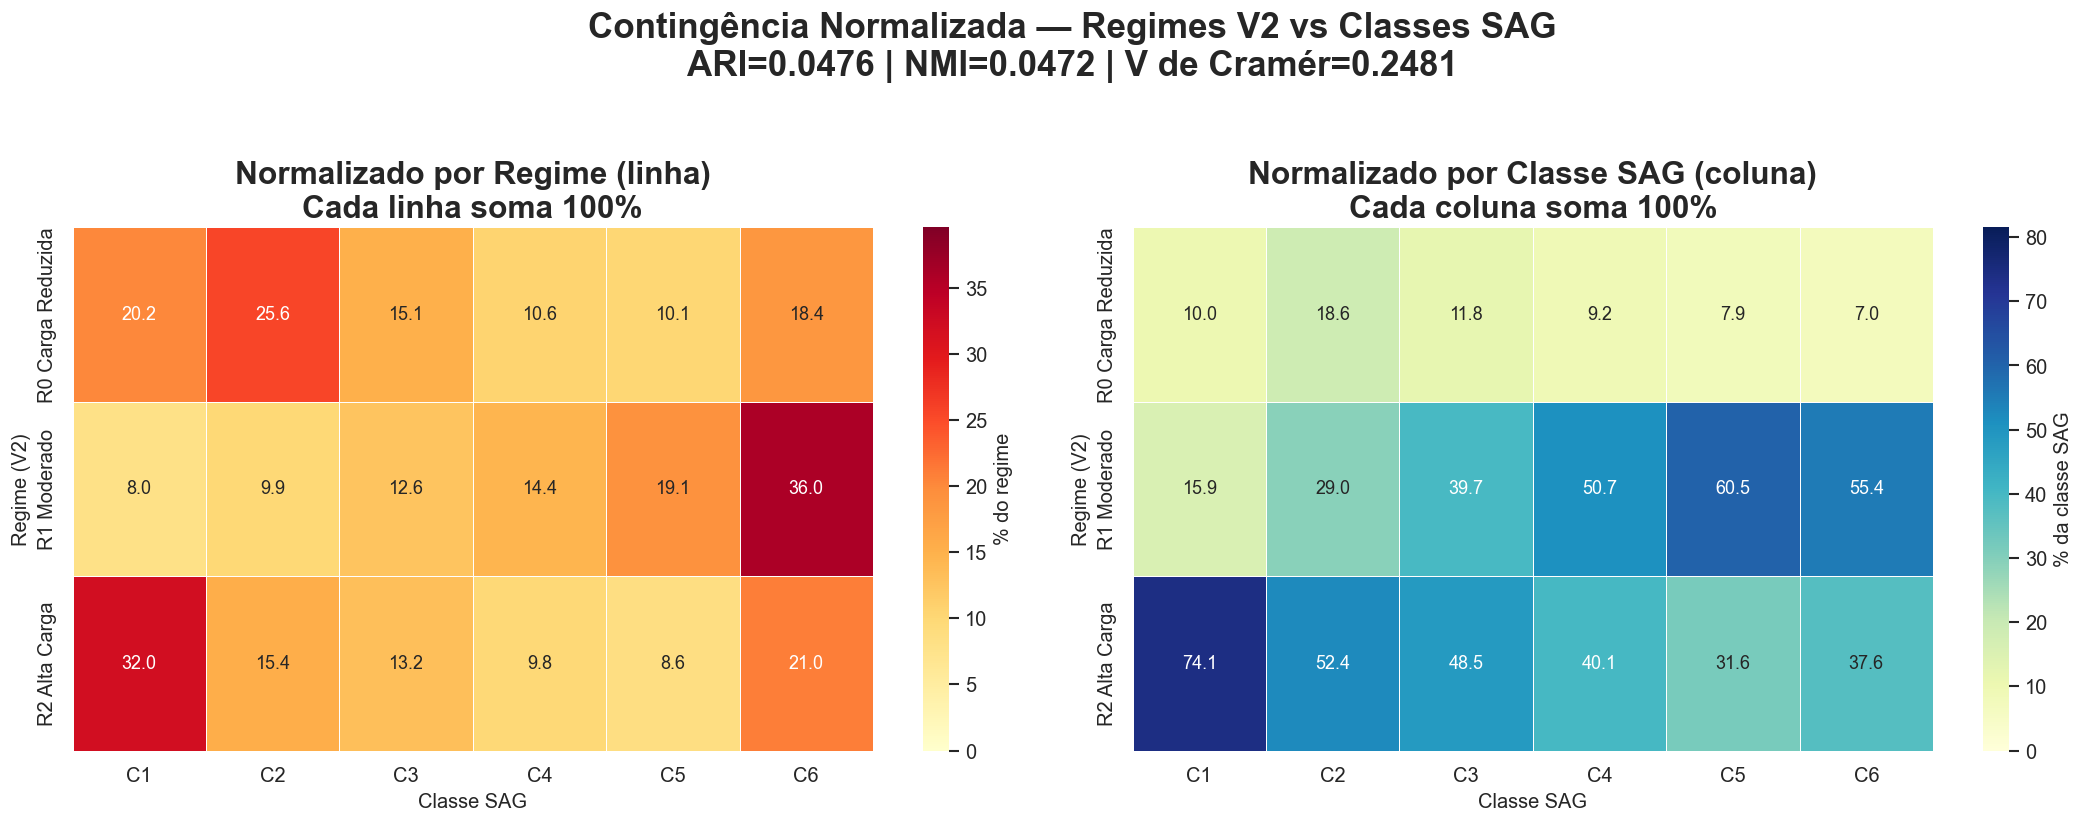

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5 + 0.5 * N_REGIMES))

# Labels formatados
regime_labels = [f"R{r} {REGIME_NAMES[r]}" for r in range(N_REGIMES)]
classe_labels = [f"C{c}" for c in range(1, 7)]

# 6a. Normalizado por LINHA (regime) — como cada regime se distribui entre classes SAG
ax = axes[0]
ct_row = pd.crosstab(df_comp["regime_int"], df_comp["classe_sag_int"], normalize="index") * 100
ct_row.index = regime_labels
ct_row.columns = classe_labels
sns.heatmap(ct_row, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "% do regime"},
            vmin=0, vmax=ct_row.values.max() * 1.1)
ax.set_xlabel("Classe SAG")
ax.set_ylabel("Regime (V2)")
ax.set_title("Normalizado por Regime (linha)\nCada linha soma 100%", fontweight="bold")

# 6b. Normalizado por COLUNA (classe SAG) — como cada classe SAG se distribui entre regimes
ax = axes[1]
ct_col = pd.crosstab(df_comp["regime_int"], df_comp["classe_sag_int"], normalize="columns") * 100
ct_col.index = regime_labels
ct_col.columns = classe_labels
sns.heatmap(ct_col, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax,
            linewidths=0.5, cbar_kws={"label": "% da classe SAG"},
            vmin=0, vmax=ct_col.values.max() * 1.1)
ax.set_xlabel("Classe SAG")
ax.set_ylabel("Regime (V2)")
ax.set_title("Normalizado por Classe SAG (coluna)\nCada coluna soma 100%", fontweight="bold")

fig.suptitle("Contingência Normalizada — Regimes V2 vs Classes SAG\n"
             f"ARI={ari:.4f} | NMI={nmi:.4f} | V de Cramér={cramers_v:.4f}",
             fontsize=21, fontweight="bold", y=1.05)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S2a_04_contingencia_normalizada.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "contingencia_normalizada", fig, "S2a_04_contingencia_normalizada.png")
plt.show()

## 9. Visualizações Complementares

**Objetivo:** Complementar a análise com duas visualizações adicionais:

1. **Boxplot de energia específica por regime:** mostra a dispersão da energia EMA em cada
   regime, com as linhas de corte das classes SAG sobrepostas. Se os regimes correspondessem
   às classes de dureza, cada boxplot estaria contido entre duas linhas de corte.

2. **Barras empilhadas:** proporção de cada classe SAG dentro de cada regime. Se houvesse
   correspondência perfeita, cada barra teria uma única cor dominante.

[db_utils] Imagem 'comparacao_regimes_vs_sag' salva para etapa s2a


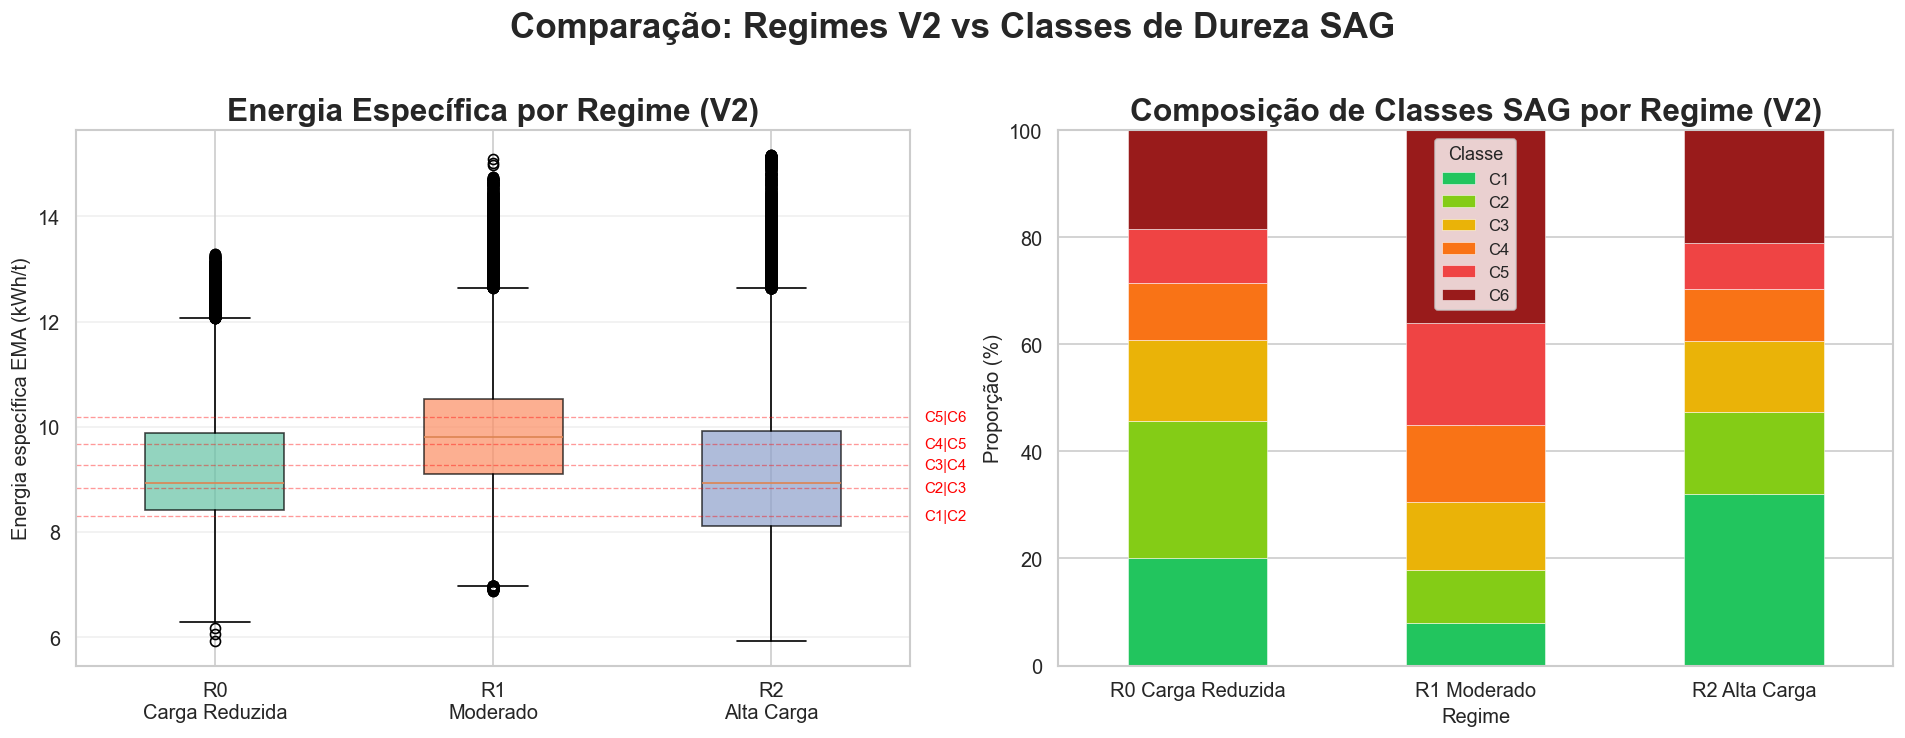

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 7a. Boxplot: energia específica por regime
ax = axes[0]
data_box = [df_comp[df_comp["regime_int"] == r]["energia_ema"].dropna().values for r in range(N_REGIMES)]
bp = ax.boxplot(data_box,
                labels=[f"R{r}\n{REGIME_NAMES[r]}" for r in range(N_REGIMES)],
                patch_artist=True, widths=0.5)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(REGIME_COLORS[i])
    patch.set_alpha(0.7)
# Linhas de threshold das classes SAG
for i in range(1, 6):
    ax.axhline(ENERGY_THRESHOLDS[i], color="red", linestyle="--", alpha=0.4, linewidth=0.8)
    ax.text(N_REGIMES + 0.55, ENERGY_THRESHOLDS[i], f"C{i}|C{i+1}", fontsize=9, color="red", va="center")
ax.set_ylabel("Energia específica EMA (kWh/t)")
ax.set_title("Energia Específica por Regime (V2)", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

# 7b. Barras empilhadas: proporção de classes por regime
ax = axes[1]
cross = pd.crosstab(df_comp["regime_int"], df_comp["classe_sag_int"], normalize="index") * 100
n_classes = len(cross.columns)
cross.plot(kind="bar", stacked=True, color=CORES_CLASSE[:n_classes], ax=ax,
           edgecolor="white", linewidth=0.3)
ax.set_xlabel("Regime")
ax.set_xticklabels([f"R{r} {REGIME_NAMES[r]}" for r in range(N_REGIMES)], rotation=0)
ax.set_ylabel("Proporção (%)")
ax.set_title("Composição de Classes SAG por Regime (V2)", fontweight="bold")
ax.legend([f"C{c}" for c in cross.columns], fontsize=10, title="Classe")
ax.set_ylim(0, 100)

fig.suptitle("Comparação: Regimes V2 vs Classes de Dureza SAG",
             fontsize=21, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S2a_03_comparacao_regimes_vs_sag.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "comparacao_regimes_vs_sag", fig, "S2a_03_comparacao_regimes_vs_sag.png")
plt.show()

## 10. Decisão: Target para Classificação Supervisionada

**Objetivo:** Definir qual variável-alvo será usada para treinar o classificador supervisionado,
com base nos resultados da comparação entre clusters e classes SAG.

In [23]:
# Análise para decisão do target
print("=" * 60)
print("  DECISÃO: TARGET PARA CLASSIFICAÇÃO SUPERVISIONADA")
print("=" * 60)

print(f"\n  Opção A: Regimes do clustering (3 classes)")
print(f"    - 3 regimes: Carga Reduzida / Moderado / Alta Carga")
print(f"    - Descobertos por aprendizado não-supervisionado")
print(f"    - Capturam dinâmica multivariada do processo")
n_regime_total = df["regime"].notna().sum()
for r in range(3):
    n = (df["regime"] == r).sum()
    print(f"    - R{r} ({REGIME_NAMES[r]:15s}): {n:>8,} ({100*n/n_regime_total:.1f}%)")

print(f"\n  Opção B: Classes SAG (6 classes)")
print(f"    - 6 classes: C1-C6 (dureza do minério)")
print(f"    - Baseadas em energia específica (sistema em produção)")
for c in range(1, 7):
    n = (df_class["classe_sag"] == c).sum()
    print(f"    - C{c} ({CLASSES_SAG[c]['nome']:20s}): {n:>8,} ({100*n/len(df_class):.1f}%)")

print(f"\n  Opção C: Classes SAG simplificadas (3 classes)")
# Agrupar: C1-C2 = Mole, C3-C4 = Médio, C5-C6 = Duro
df["dureza_3c"] = np.nan
mask_class = df["classe_sag"].notna()
df.loc[mask_class & (df["classe_sag"] <= 2), "dureza_3c"] = 0  # Mole
df.loc[mask_class & (df["classe_sag"] >= 3) & (df["classe_sag"] <= 4), "dureza_3c"] = 1  # Médio
df.loc[mask_class & (df["classe_sag"] >= 5), "dureza_3c"] = 2  # Duro
DUREZA_NAMES = {0: "Mole (C1-C2)", 1: "Médio (C3-C4)", 2: "Duro (C5-C6)"}
for d in range(3):
    n = (df["dureza_3c"] == d).sum()
    total_d3c = df["dureza_3c"].notna().sum()
    print(f"    - D{d} ({DUREZA_NAMES[d]:15s}): {n:>8,} ({100*n/total_d3c:.1f}%)")

print(f"\n  Concordância ARI: {ari:.4f}")
print(f"  Concordância NMI: {nmi:.4f}")
print(f"  V de Cramér: {cramers_v:.4f}")

# Decisão automática baseada nos resultados
print(f"\n  ► TARGET SELECIONADO: Regimes do clustering (3 classes)")
print(f"    Motivo: Os regimes capturam a dinâmica operacional multivariada")
print(f"    do moinho, enquanto as classes SAG se baseiam apenas em energia")
print(f"    específica. Os 3 regimes são operacionalmente interpretáveis")
print(f"    e balanceados. As classes SAG ficam como variável complementar")
print(f"    para validação cruzada na Sprint 3.")

  DECISÃO: TARGET PARA CLASSIFICAÇÃO SUPERVISIONADA

  Opção A: Regimes do clustering (3 classes)
    - 3 regimes: Carga Reduzida / Moderado / Alta Carga
    - Descobertos por aprendizado não-supervisionado
    - Capturam dinâmica multivariada do processo
    - R0 (Carga Reduzida ):   90,119 (14.2%)
    - R1 (Moderado       ):  288,740 (45.6%)
    - R2 (Alta Carga     ):  254,126 (40.1%)

  Opção B: Classes SAG (6 classes)
    - 6 classes: C1-C6 (dureza do minério)
    - Baseadas em energia específica (sistema em produção)
    - C1 (Muito Macio         ):   74,750 (20.8%)
    - C2 (Macio               ):   51,009 (14.2%)
    - C3 (Médio               ):   47,205 (13.1%)
    - C4 (Duro                ):   42,401 (11.8%)
    - C5 (Muito Duro          ):   47,162 (13.1%)
    - C6 (Extremamente Duro   ):   96,833 (26.9%)

  Opção C: Classes SAG simplificadas (3 classes)
    - D0 (Mole (C1-C2)   ):  125,759 (35.0%)
    - D1 (Médio (C3-C4)  ):   89,606 (24.9%)
    - D2 (Duro (C5-C6)   ):  14

## 11. Salvamento do Dataset Rotulado

**Objetivo:** Persistir o dataset completo com todos os rótulos gerados nesta etapa, tanto em disco (Parquet) quanto no PostgreSQL. O dataset final contém as 27 variáveis originais de processo, o regime operacional (da Sprint 1c — clustering V2), a classe SAG (C1-C6), a dureza simplificada (3 classes), a energia específica bruta e suavizada (EMA), o flag de estabilidade e a capacidade máxima calculada.

**Saídas:**
- Tabela `dados_rotulados`: dataset completo com variáveis de processo + regime + classe SAG + energia específica + flag de estabilidade
- Tabela `s2a_resumo_carimbamento`: distribuição de classes SAG com contagens e percentuais de estabilidade

In [24]:
# Preparar dataset rotulado final
# Incluir: variáveis originais + regime (clustering) + classe SAG + metadados preditor
cols_salvar = [
    # Variáveis de processo originais
    *[c for c in df.columns if c.endswith("_pipoint")],
    # Labels
    "regime",           # Clustering v2 (target principal)
    "classe_sag",       # Preditor SAG C1-C6
    "dureza_3c",        # SAG simplificado (Mole/Médio/Duro)
    # Metadados do preditor
    "energia_raw",
    "energia_ema",
    "cv_alimentacao",
    "is_stable",
    "capacidade_max",
]
cols_salvar = [c for c in cols_salvar if c in df.columns]

df_save = df[cols_salvar].copy()

# Salvar parquet local
out_path = DATA_LABEL / "dataset_rotulado.parquet"
df_save.to_parquet(out_path)
print(f"Dataset rotulado salvo: {out_path}")
print(f"  Shape: {df_save.shape[0]:,} x {df_save.shape[1]}")
print(f"  Colunas: {df_save.columns.tolist()}")

# Salvar métricas de comparação
metricas = pd.DataFrame([{
    "ari": ari,
    "nmi": nmi,
    "cramers_v": cramers_v,
    "n_registros": len(df_comp),
    "n_regimes": 3,
    "n_classes_sag": len(df_comp["classe_sag_int"].unique()),
    "pct_estavel": 100 * df["is_stable"].sum() / len(df),
}])
metricas.to_csv(DATA_PROC / "s2a_metricas_comparacao.csv", index=False)
print(f"\nMétricas salvas: {DATA_PROC / 's2a_metricas_comparacao.csv'}")

# ==============================================================================
# Persistência no PostgreSQL
# ==============================================================================
print("\nSalvando no PostgreSQL...")

# 1. dados_rotulados — dataset com variáveis de processo + labels
cols_db = [c for c in df_save.columns if c.endswith("_pipoint")]
df_rotulados = df_save.reset_index()
df_rotulados_db = df_rotulados[["Timestamp"] + cols_db + ["regime", "classe_sag", "energia_raw", "is_stable"]].copy()
# Renomear energia para match do schema
df_rotulados_db.rename(columns={"energia_raw": "energia_especifica"}, inplace=True)
# Tipos corretos
df_rotulados_db["regime"] = df_rotulados_db["regime"].astype("Int64")
df_rotulados_db["classe_sag"] = df_rotulados_db["classe_sag"].astype("Int64")
salvar_dataframe(df_rotulados_db, "dados_rotulados")

# 2. s2a_resumo_carimbamento — distribuição de classes SAG
resumo_list = []
for c in sorted(df_class["classe_sag"].unique()):
    mask = df_class["classe_sag"] == c
    n = mask.sum()
    n_est = df_class.loc[mask, "is_stable"].sum() if "is_stable" in df_class.columns else 0
    resumo_list.append({
        "classe_sag": int(c),
        "n_registros": int(n),
        "percentual": round(100 * n / len(df_class), 2),
        "n_estaveis": int(n_est),
        "pct_estaveis": round(100 * n_est / n, 2) if n > 0 else 0,
    })
salvar_dataframe(pd.DataFrame(resumo_list), "s2a_resumo_carimbamento")

print("\nDados de carimbamento salvos no PostgreSQL.")

Dataset rotulado salvo: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\dataset_rotulado.parquet
  Shape: 632,985 x 35
  Colunas: ['1010_BRITAGEM _ SL01 _ NÍVEL_pipoint', '1025_RETOMADA_SL01_NIVEL_pipoint', '1025_RETOMADA _ AL01 _ SETPOINT_pipoint', '1025_RETOMADA _ AL02 _ SETPOINT_pipoint', '1025_RETOMADA _ AL03 _ SETPOINT_pipoint', '1025_RETOMADA _ TR02 _ BALANÇA_pipoint', '1025_RETOMADA _ TR02 _ CORRENTE_pipoint', '1030_MOAGEM _ CX01 _ NÍVEL_pipoint', '1030_MOAGEM _ HCALIMENTAÇÃO _ DENSIDADE_pipoint', '1030_MOAGEM _ HCALIMENTAÇÃO _ VAZÃO_pipoint', '1030_MOAGEM _ HC _ PRESSÃO_pipoint', '1030_MOAGEM _ MO01MANCALENTRADA _ PRESSÃO_pipoint', '1030_MOAGEM _ MO01MANCALSAÍDA _ PRESSÃO_pipoint', '1030_MOAGEM _ MO01ÁGUADESCARGAMOINHO _ VAZÃO_pipoint', '1030_MOAGEM _ MO01_VAZAO_pipoint', '1030_MOAGEM _ MO01 _ CORRENTE_pipoint', '1030_MOAGEM _ MO01 _ OUVIDOELETRÔNICO_pipoint', '1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint', '1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint', '1030_MOAGEM _ MO01 _ TORQUE_pi

## 12. Resumo

**Objetivo:** Consolidar os resultados do pipeline de carimbamento, apresentando as métricas-chave e a decisão final sobre a variável-alvo para a classificação supervisionada.

**Resultados esperados:**
- Classificação SAG aplicada sobre os 632.985 registros limpos, com percentual de cobertura e estabilidade
- Distribuição das 6 classes de dureza (C1-C6)
- Métricas de concordância entre regimes e classes SAG (ARI, NMI, V de Cramér)

**Decisão:** Os 3 regimes operacionais descobertos pelo clustering V2 (Carga Reduzida, Moderado, Alta Carga) serão utilizados como target para a classificação supervisionada. As classes SAG permanecem no dataset como variável complementar para validação cruzada na Sprint 3.

**Justificativa:** A concordância entre regimes e dureza, medida por ARI, NMI e V de Cramér, indica se os regimes capturam a mesma informação que as classes SAG ou se representam dimensões operacionais distintas. Os regimes integram múltiplas variáveis de processo (potência, pressão, corrente, torque), enquanto as classes SAG dependem exclusivamente da energia específica.

In [25]:
elapsed = time.time() - t0
print("\n" + "=" * 60)
print("  RESUMO — CARIMBAMENTO COM PREDITOR SAG (S2a)")
print("=" * 60)
print(f"  Tempo total: {elapsed:.0f}s")
print(f"  Registros: {len(df):,}")
print(f"  Período: {df.index.min().strftime('%d/%m/%Y')} a {df.index.max().strftime('%d/%m/%Y')}")

print(f"\n  PREDITOR SAG:")
print(f"    Classificados: {df['classe_sag'].notna().sum():,} ({100*df['classe_sag'].notna().sum()/len(df):.1f}%)")
print(f"    Estáveis: {df['is_stable'].sum():,} ({100*df['is_stable'].sum()/len(df):.1f}%)")
dist = df[df['classe_sag'].notna()]['classe_sag'].astype(int).value_counts(normalize=True).sort_index()
print(f"    Classes: " + " ".join(f"C{c}={100*v:.0f}%" for c, v in dist.items()))

print(f"\n  COMPARAÇÃO CLUSTERS vs SAG:")
print(f"    ARI: {ari:.4f}")
print(f"    NMI: {nmi:.4f}")
print(f"    V de Cramér: {cramers_v:.4f}")

print(f"\n  TARGET SELECIONADO: Regimes do clustering (3 classes)")

print(f"\n  Figuras: {len(list(FIGURES_DIR.glob('S2a_*.png')))} em {FIGURES_DIR}")
print(f"  Dataset rotulado: {DATA_LABEL / 'dataset_rotulado.parquet'}")
print("=" * 60)


  RESUMO — CARIMBAMENTO COM PREDITOR SAG (S2a)
  Tempo total: 60s
  Registros: 632,985
  Período: 01/08/2024 a 01/03/2026

  PREDITOR SAG:
    Classificados: 359,360 (56.8%)
    Estáveis: 359,360 (56.8%)
    Classes: C1=21% C2=14% C3=13% C4=12% C5=13% C6=27%

  COMPARAÇÃO CLUSTERS vs SAG:
    ARI: 0.0476
    NMI: 0.0472
    V de Cramér: 0.2481

  TARGET SELECIONADO: Regimes do clustering (3 classes)

  Figuras: 4 em C:\ScriptsDatamindsPIP\4-Projeto aplicado\figures\02_sprint2
  Dataset rotulado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\dataset_rotulado.parquet


In [26]:
# ==============================================================================
# Exportar notebook para HTML (com todos os outputs)
# ==============================================================================
from pathlib import Path
from IPython.display import display, Javascript
import time

display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)

from nbconvert import HTMLExporter
import nbformat

_nb_path = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\notebooks\02_sprint2\a_carimbamento_preditor.ipynb")
_html_dir = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\html")
_html_dir.mkdir(parents=True, exist_ok=True)

with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "a_carimbamento_preditor.html"
_out_path.write_text(_html_body, encoding="utf-8")
print("HTML exportado:", _out_path)

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\a_carimbamento_preditor.html
